### **3.3 Exploring Random Walks and Stationarity**

In this practical you will explore the concept of a **random walk**, a foundational idea in time series analysis and financial modelling. The activity is divided into four parts to help you build a strong understanding through simulation and real data analysis.

- **Part 1**: Understanding Stationary vs Non_Stationary Processes.

You will begin by simulating and visualising two time series: one **stationary** and one **non-stationary**.

- **Part 2**: Simulating a Random Walk.

Next, you will simulate a **random walk** in Python - a type of non-stationary process where each value depends on the previous one plus random noise.

- **Part 3**: Predicting a Random Walk.

In this section you will attempt to make naive forecasts of a random walk and evaluate how predictable (or unpredictable) it really is.

- **Part 4**: Analysing Real Data (Google Stock Prices)

Finally, you will load **Alphabet's (Google) historical stock prices** and assess whether the time series behaves like a random walk.

---

This activity will help you:

- Understand the differences between **stationary** and **non-stationary** time series

- Simulate and analyse a **random walk**

- Evaluate the **predictability** of a random walk

- Apply your understanding to a real-world dataset

**Required file:** `GOOGL.csv`

---

This activity has been adapted from [this book](https://www.manning.com/books/time-series-forecasting-in-python-book)

**Preparation: Load the Libraries**

To begin, we will load the libraries required for time series analysis and visualisation. These include:

- `pandas` amd `numpy` for data handling

- `matplotlib` for plotting

- `statsmodels` for time series decomposition, autocorrelation plots, and stationarity testing

We have also included a warning suppression line to keep the output clean, and `%matplotlib inline` to display plots within the norebook.

In [36]:
# Install required packages if not already installed
# python -m pip install scikit-learn

# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf

# Data manipulation
import pandas as pd
import numpy as np

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error

#### **Part 1: Understanding Stationary vs Non-Stationary Processes**

A **stationary process** is one whose key statistical properties - **mean**, **variance**, and **autocorrelation** - remain **constant over time**. Many time series models, such as ARIMA, assume the input data is stationary to produce reliable forecasts.

We can represent a simple time series process using the equation:

$$y_t=C+\alpha_1y_{t-1}+\epsilon_t$$

Where:

- $C$ is a constant
- $\alpha_{1}$ is the **root** of the process
- $\epsilon_{t}$ is random error (white noise)

The **stationarity** of this process depends on the value of $\alpha_{1}$:

- If $\alpha_{1}$ **is between -1 and 1**, the process is **stationary**
- If $\alpha_{1}=1$ (also known as unit root), the process is **non-stationary**

**1.1 Simulating Stationary and Non-Stationary Processes**

To better understand stationarity, we will simulate two different time series:

- One with a **stationary process**, where the autoregressive root $\alpha=0.5$
- One with a **non-stationary process**, where $\alpha=1$, resulting in a unit root

This will allow us to **visualise the difference** between a stationary and a non-stationary series.

In [3]:
# Let's simulate the process of testing stationarity
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)

    # Assuming that the root unit (alpha) is 0.5
    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        # Assuming the root unit (alpha) is 1
        alpha = 1
        process[0] = 10

    for i in range(400):
        if i + 1 < 400:
            process[i + 1] = alpha * process[i] + np.random.normal()
        else:
            break
    return process

In [4]:
# Simulate the stationary and non-stationary
stationary_process = simulate_process(is_stationary=True)
non_stationary_process = simulate_process(is_stationary=False)

The following plot below shows the difference between a **stationary** and a **non-stationary** process:

- The **stationary series** (solid line) fluctuates around a constant mean with a stable variance.
- The **non-stationary series** (dashed line) shows a drifting pattern, with values that wander further from the starting point over time.

This visual comparison helps highlight why testing for stationarity is an important step in time series analysis.

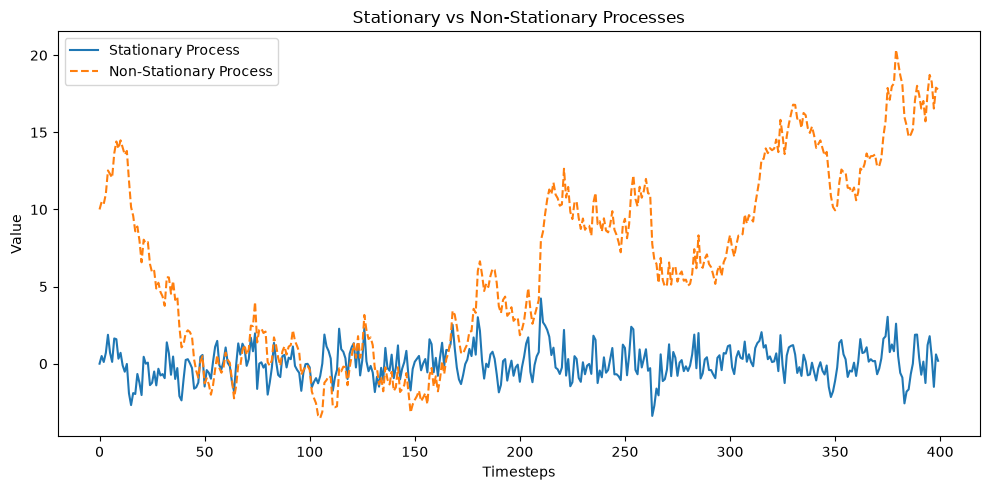

In [5]:
# Plotting the stationary and non-stationary processes
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(stationary_process, linestyle='-', label='Stationary Process')
ax.plot(non_stationary_process, linestyle='--', label='Non-Stationary Process')
ax.legend(loc=2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
plt.title("Stationary vs Non-Stationary Processes")
plt.tight_layout()
plt.show()

By looking at the two series, you can get an idea of how **stationary** and **non-stationary** processes behave over time.

Notice that the **stationary process** does not show a long-term increase or decrease - it fluctuates around a constant level. This is because **stationary series have constant statistical properties**, such as **mean** and **variance**, that remain stable over time.

In contrast, the **non-stationary process** tends to drift and does not return to a fixed level, indicating that its properties change over time.

**1.2 Mean and Variance of the simulated processes**

The following code can be used for computing the **cumulative mean** at each time point for both processes.

In [6]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []

    for i in range(1, len(process) + 1):
        mean_func.append(np.mean(process[:i]))

    return np.array(mean_func)

In [7]:
# Compute for stationary mean and non-stationary mean over time
stationary_mean = mean_over_time(stationary_process)
non_stationary_mean = mean_over_time(non_stationary_process)

The plot below shows the **cumulative mean** for the stationary and non-stationary processes.

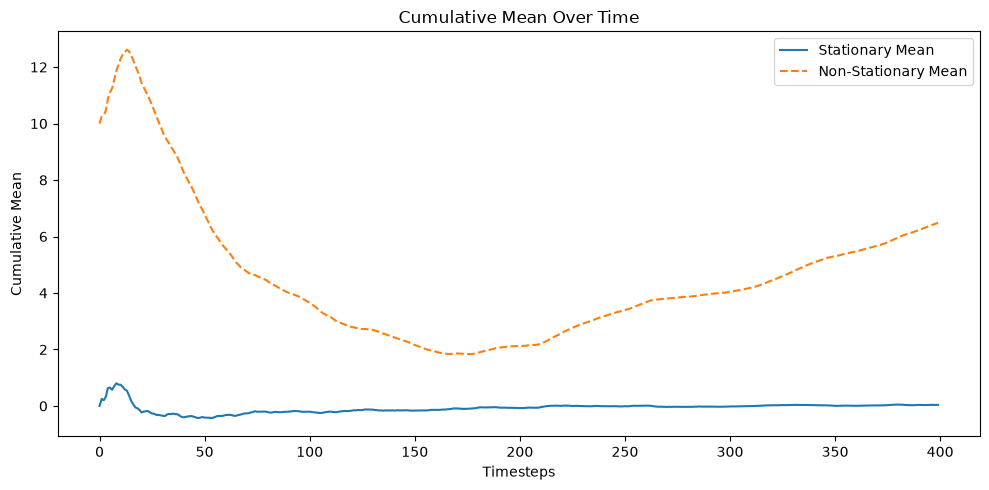

In [8]:
# Plot the cumulative mean over time for both processes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stationary_mean, linestyle='-', label='Stationary Mean')
ax.plot(non_stationary_mean, linestyle='--', label='Non-Stationary Mean')
ax.legend(loc=1)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Cumulative Mean")
plt.title("Cumulative Mean Over Time")
plt.tight_layout()
plt.show()

Now we can perform a similar process to track how the **variance** changes over time for each series.

In [9]:
def var_over_time(process: np.array) -> np.array:
    var_func = []

    for i in range(1, len(process) + 1):
        var_func.append(np.var(process[:i]))

    return np.array(var_func)

In [10]:
# Variance over time for both processes
stationary_variance = var_over_time(stationary_process)
non_stationary_variance = var_over_time(non_stationary_process)

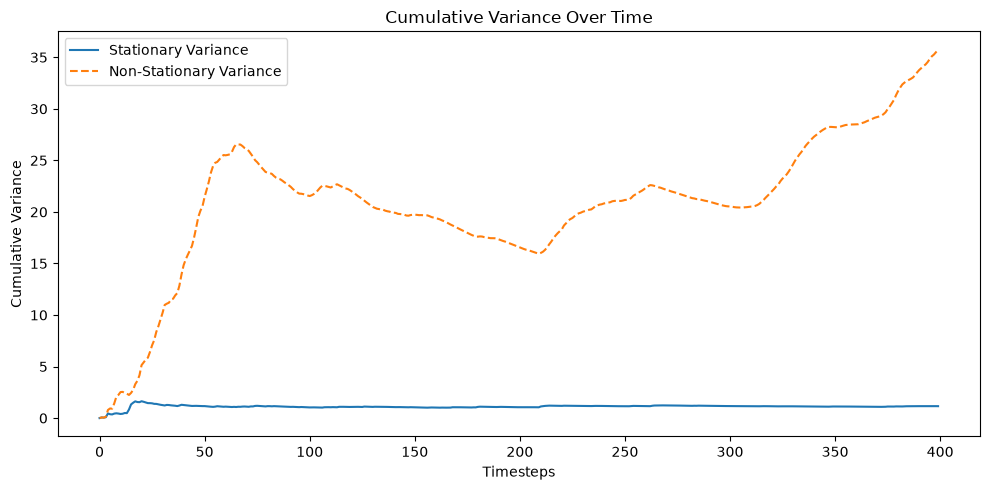

In [11]:
# Plot the cumulative variance over time for both processes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stationary_variance, linestyle='-', label='Stationary Variance')
ax.plot(non_stationary_variance, linestyle='--', label='Non-Stationary Variance')
ax.legend(loc=2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Cumulative Variance")
plt.title("Cumulative Variance Over Time")
plt.tight_layout()
plt.show()

The plot clearly shows the difference between stationary and non-stationary processes.

- In the **stationary** series, both the mean and variance **stabilise quickly and remain relatively constant**.
- In contrast, the **non-stationary** series shows a **drifting mean** and **increasing variance**, which are signs that its statistical properties are changing over time.

**1.3 Testing for stationarity**

Before we can apply most time series forecasting models, we need to verify whether the data is **stationary**.

To do this, we use the **Augmented Dickey-Fuller (ADF) test**, a statistical test designed to detect the presence of a **unit root**.

- **Null hypothesis ($H_{0}$)**: The time series has a **unit root** → it is **non-stationary**
- **Alternative hypothesis ($H_{1}$)**: The time series has **no unit root** → it is **stationary**

If the **p-value** from the test is **less than 0.05**, we can reject the null hypothesis and conclude that the time series is likely stationary.

We will apply the ADF test to both our **simulated stationary** and **non-stationary** series to confirm the differences statistically.

More info: [statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.tsa.stattools.adfuller.html)

In [12]:
# Define a function to perform the Augmented Dickey-Fuller test
def run_adf_test(series, label):
    print(f'Augmented Dickey-Fuller Test: {label}')
    result = adfuller(series, autolag='AIC')
    labels = ['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)
    
    for key, value in result[4].items():
        out[f'Critical Value ({key})'] = value
    
    print(out.to_string())
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis (reject H0), the series is stationary.")
    else:
        print("Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.")

In [13]:
# Apply the ADF test to both processes
run_adf_test(stationary_process, "Stationary Process")
run_adf_test(non_stationary_process, "Non-Stationary Process")

Augmented Dickey-Fuller Test: Stationary Process
ADF Test Statistic            -1.217185e+01
p-value                        1.414881e-22
#Lags Used                     0.000000e+00
Number of Observations Used    3.990000e+02
Critical Value (1%)           -3.446846e+00
Critical Value (5%)           -2.868811e+00
Critical Value (10%)          -2.570643e+00
Strong evidence against the null hypothesis (reject H0), the series is stationary.
Augmented Dickey-Fuller Test: Non-Stationary Process
ADF Test Statistic              -1.098964
p-value                          0.715485
#Lags Used                       0.000000
Number of Observations Used    399.000000
Critical Value (1%)             -3.446846
Critical Value (5%)             -2.868811
Critical Value (10%)            -2.570643
Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.


#### **Part 2: Simulate a Random Walk**

In this section, we will simulate a basic **random walk** - a time series where each value is the sum of the previous value and a random step. Random walks are often used to model stock prices and other financial data due to their unpredictable, memoryless nature.

**2.1 Steps**

1. **Set a random seed** using `np.random.seed(42)` to ensure reproducibility - the same random numbers will be generated each time the code is run.

2. Generate **1,000 random steps** from a standard normal distribution using `np.random.standard_normal(1000)`.

3. Set the first value of the series to 0.

4. Use `np.cumsum()` to compute the **cumulative sum** of the steps, which forms the random walk.

This process gives us a synthetic time series that we can analyse and compare to real-world financial data later.

In [14]:
# Set the seed for reproducibility
np.random.seed(42)

# Generate 1000 random numbers from a standard normal distribution (mean=0, std=1)
steps = np.random.standard_normal(1000)

# Initialise the first value of the series
steps[0] = 0

# Compute the cumulative sum to simulate a random walk
random_walk = np.cumsum(steps)

**2.2 Visualise the Simulated Random Walk**

Now that we have generated the random walk, we will plot it to observe its behaviour over time.

The plot shows how the series evolves from an initial value of 0 by taking random steps. Even though the changes are random at each step, the overall path can drift significantly - which is a key characteristic of random walks.

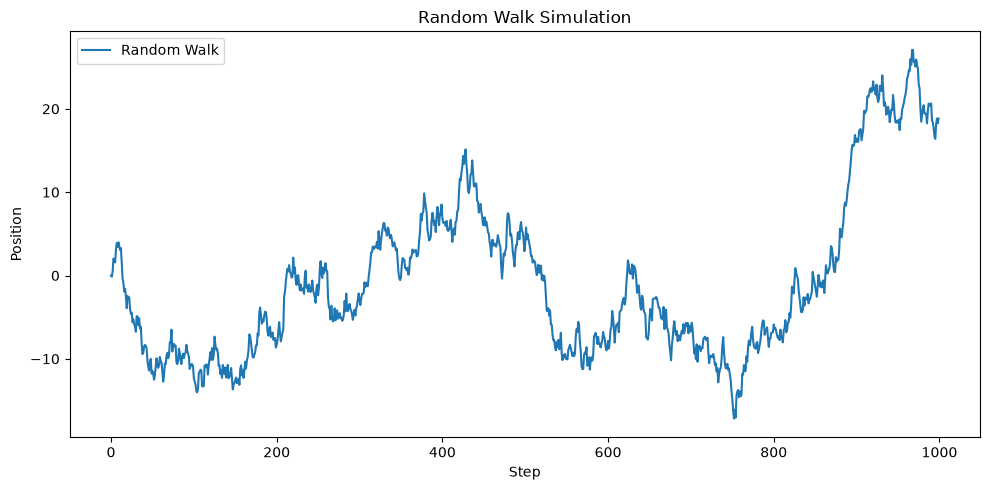

In [15]:
# Plot and visualise the random walk
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(random_walk, linestyle='-', label='Random Walk')
ax.legend(loc=2)
ax.set_title('Random Walk Simulation')
ax.set_xlabel('Step')
ax.set_ylabel('Position')
plt.tight_layout()

# Save the figure as a PNG file
plt.savefig('random_walk_simulation.png', dpi=300)

**2.3 Is our simulation a Random Walk?**

We have generated a new time series that we claim is a **random walk**. In this section, we will verify that claim by checking its key characteristics - specifically, whether it is **non-stationary** and exhibits behaviour consistent with a random walk. We will use the **Augmented Dickey-Fuller (ADF) test** to support our conclusion.

**Note**: A **random walk** is a time series whose **first difference** is **stationary** and **uncorrelated**.

**2.3.1 Check if the series is stationary**

By definition, a random walk is not stationary (but... its first difference is stationary). So first, we test for stationarity on the time series.

In [16]:
run_adf_test(random_walk, "Random Walk Process")

Augmented Dickey-Fuller Test: Random Walk Process
ADF Test Statistic              -0.965952
p-value                          0.765479
#Lags Used                       0.000000
Number of Observations Used    999.000000
Critical Value (1%)             -3.436913
Critical Value (5%)             -2.864437
Critical Value (10%)            -2.568313
Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.


Since the p-value is larger than 0.05 we **fail to reject the null hypothesis** of the ADF test (the series has a unit root).

Therefore, the time series is **likely non-stationary**.

**2.3.2 Differentiating the time series**

Since our simulated series shows no seasonal pattern, a first-order difference is appropriate. If the differenced series is stationary, it supports the idea that the original series is a **random walk**.

We use `np.diff()` with `n=1` to compute the difference between consecutive values.

In [17]:
# Apply first-order differencing to the simulated random walk
# This is done to make the series stationary by removing trends and seasonality.
diff_random_walk = np.diff(random_walk, n=1)

After applying first-order differencing to our simulated random walk, we can now visualise the result.

If the differenced series looks like a stable, mean-reverting process with no obvious trend, this supports the idea that the **original series is a random walk** - since a random walk's first difference should be **stationary and uncorrelated**.

The plot below shows the differenced series.

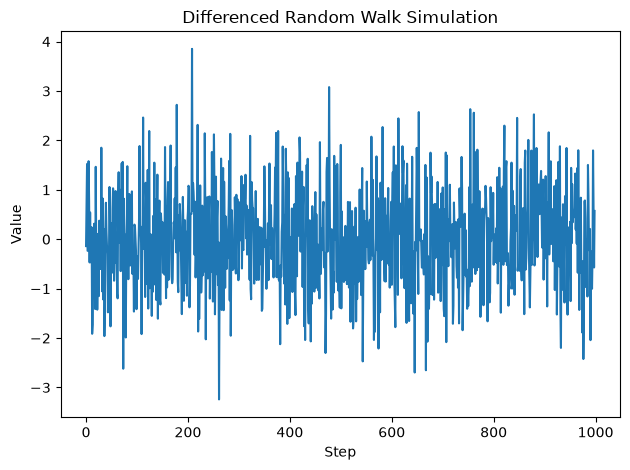

In [18]:
# Visualise the differenced simulated random walk
plt.plot(diff_random_walk, linestyle='-', label='Differenced Random Walk')
plt.title('Differenced Random Walk Simulation')
plt.xlabel('Step')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

**2.3.3 Testing for Stationarity of the First Difference**

If the first-differenced series is **stationaey**, we should see:

- A **low p-value** (typically < 0.05)
- Rejection of the null hypothesis (presence of a unit root)

In [19]:
run_adf_test(diff_random_walk, "Differenced Random Walk Process")

Augmented Dickey-Fuller Test: Differenced Random Walk Process
ADF Test Statistic             -31.789311
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    998.000000
Critical Value (1%)             -3.436919
Critical Value (5%)             -2.864440
Critical Value (10%)            -2.568314
Strong evidence against the null hypothesis (reject H0), the series is stationary.


This result supports our claim that the original series is a **random walk**, since one of its key properties is that its **first difference is stationary**.

**2.3.4 Plot ACF**

Plotting the **autocorrelation function (ACF)** is a helpful way to understand the structure of a time series. In this case, we use the ACF to assess whether the **first-differenced series** resembles white noise.

In a **non-stationary** time series, autocorrelations **often decay** slowly and remain high over many lags, especially in processes with a unit root like a random walk.

This is a key sign that the series does not revert to a stable mean, which violates the assumptions of stationarity. While this behaviour shows persistence, it is not the same as true long-memory processes in the technical sense.

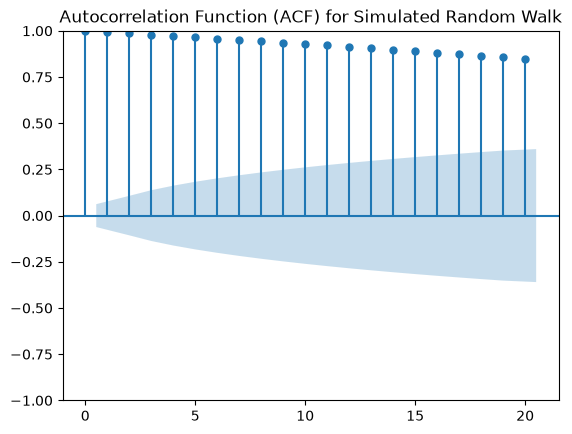

In [20]:
# Plot ACF for the stationary process
plot_acf(random_walk, lags=20, title='Autocorrelation Function (ACF) for Simulated Random Walk')
plt.show()

If the differenced series is a result of a **random walk**, we expect the ACF to show:

- **No significant autocorrelation** beyond lag 0
- A quick drop-off within the confidence bounds

This would indicate that the differenced series is **uncorrelated** and **stationary**, supporting the conclusion that our simulation is a **random walk**.

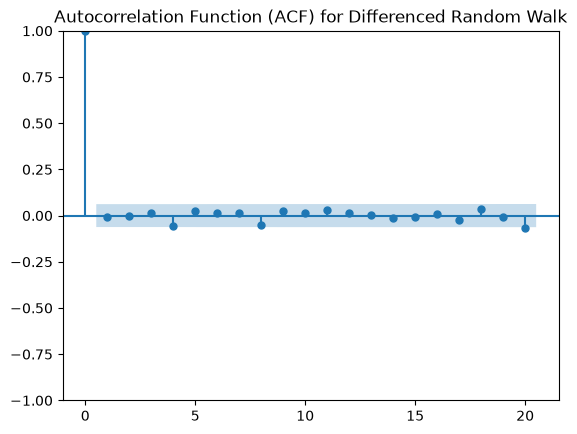

In [21]:
# Plot ACF for the differenced random walk
plot_acf(diff_random_walk, lags=20, title='Autocorrelation Function (ACF) for Differenced Random Walk')
plt.show()

The ACF plots provide visual confirmation of the theoretical behaviour of stationary and non-stationary processes.

- In the **stationary series**, autocorrelation quickly drops off, indicating weak dependence beyond short lags.
- In the **non-stationary series**, autocorrelation remains strong across all 20 lags, reflecting the memory and non-reverting nature of a unit root process.

This confirms what we expect: **non-stationary series are highly persistent, while stationary ones tend to fluctuate around a stable mean**.

#### **Part 3: Predicting a Random Walk**

Now that we understand what a **random walk** is and how to identify one, we can explore how to forecast it.

This might seem counterintuitive - after all, a random walk progresses through **unpredictable random steps**. Since the next value is driven entirely by noise, we **can't meaningfully predict** it using statistical learning or traditional time series models.

In this case, the best we can do is rely on **naive forecasting methods**. The most appropriate approach is to simply forecast the **last observed value**, since there is no consistent pattern to learn from.

Other methods like using the **historical mean** are less effective in this context, because random walks do not revert to a mean.

**3.1 Forecasting a long horizon**

Let's assign our simulated random walk to a DataFrame with a single column called `value`. Then we divide it into:

- **Training set** the first 80% of the data (used to generate the forecast)
- **Test set** the remaining 20% (used to evaluate forecast accuracy)

This split allows us to mimic a real-world scenario where we train a model on past data and predict future values.

In [23]:
# We assign a random walk to a DataFrame. It contains a single column called value.
df = pd.DataFrame({'value': random_walk})

# Split the data into training and testing sets (80% training, 20% testing)
train = df[:800]
test = df[800:]

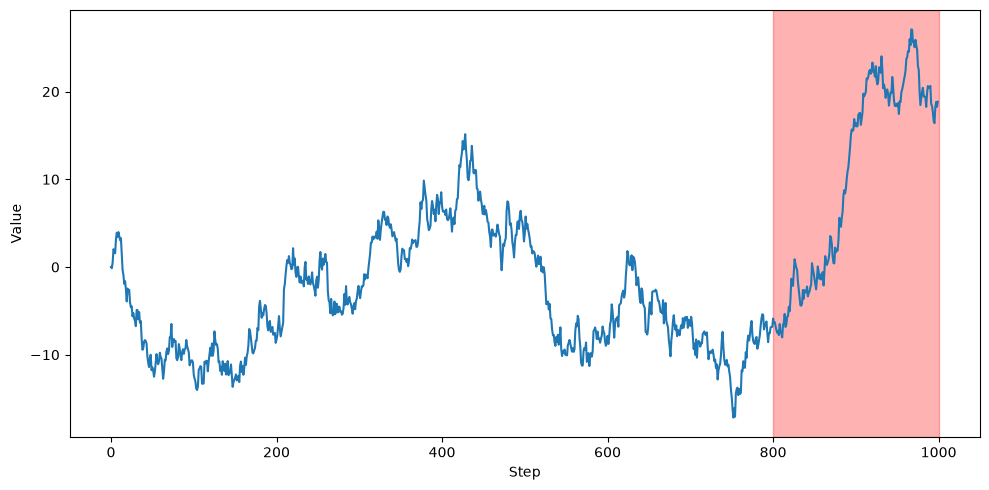

In [25]:
# Plot of train/test split of the generated random walk
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(random_walk)
ax.set_xlabel("Step")
ax.set_ylabel("Value")
ax.axvspan(800, 1000, color='red', alpha=0.3, label='Test Set')
plt.tight_layout()
plt.show()

**3.1.1 Forecasting using the Historical Mean**

In [26]:
# Use naive forecasting: historical mean
mean = np.mean(train['value'])

# Predict the historical mean for the test set
test.loc[:, 'pred_mean'] = mean

test.head()

,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


**What does this mean?** We got an historical mean of -3.68. This means that we will forecast that the next 200 timesteps of our simulated random walk will have a value of -3.68.

**3.1.2 Forecasting using the Last Value**

In [27]:
# Forecasting using the last known value (naive forecast)
last_value = train['value'].iloc[-1]

# Predict the last known value for the test set
test.loc[:, 'pred_last'] = last_value

test.head()

,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


**What does this mean?** This method yields forecasts with a constant value of -6.81.

**3.1.3 Forecasting with Drift method**

The **drift method** is a simple forecasting technique that extends the idea of using the **last known value**, but allows the forecast to **drift upward or downward over time**.

It works by calculating the **average change per time step** in the training data - essentially, the **slope** between the first and last point - and then projecting that trend forward.

**How it works:**

- Take the first value $y_{i}$, and the last value $y_{f}$ of the training set.
- Compute the **slope** as:

$$slope=\frac{y_{f}-y_{i}}{n-1}$$

when $n$ is the number of observations in the training set.
- Use this slope to **linearly extrapolate** future values.

Since the random walk starts at 0 in our simulation, we can use this method directly by plugging in the last value of the training set and the total number of steps.

In [29]:
# Forecast using the drift method: the last known value plus the average change in the training set

# Step 1: Define the change in the x-axis (number of time steps - 1)
deltaX = 800 - 1

# Step 2: Calculate the change in the y-axis (difference between the last and first value in the training set)
deltaY = train['value'].iloc[-1] - train['value'].iloc[0]

# Step 3: Calculate the slope (drift) of the training set
slope = deltaY / deltaX

# Output the slope for verification
print(f"Slope (Drift): {slope:.4f}")

Slope (Drift): -0.0085


In [32]:
# Forecast the next 200 time steps using the drift method

# Step 4: Create an array of future time steps (from 1 to 200)
future_steps = np.arange(1, 201, 1)

# Step 5: Calculate the forecasted values using the drift method
forecast = train['value'].iloc[-1] + slope * future_steps

# Step 6: Assign the predictions to the test set
test.loc[:, 'pred_drift'] = forecast

# View the first few rows of the test set with the drift predictions
test.head()


,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.823477
801,-6.392708,-3.677206,-6.814947,-6.832006
802,-6.296588,-3.677206,-6.814947,-6.840536
803,-6.758863,-3.677206,-6.814947,-6.849065
804,-7.193359,-3.677206,-6.814947,-6.857594


To generate the drift-based forecast:

1. We created a sequence of 200 future time steps (step-ahead values from 1 to 200).

2. Each forecast value is calculated by starting from the **last known value** of the training set and adding the drift multiplied by the number of steps ahead.

3. The result is a linearly increasing or decreasing forecast that extends the trend observed in the training data.

This method assumes that the average change observed in the traing set continues into the future.

**Forecasting errors for the 3 methods**

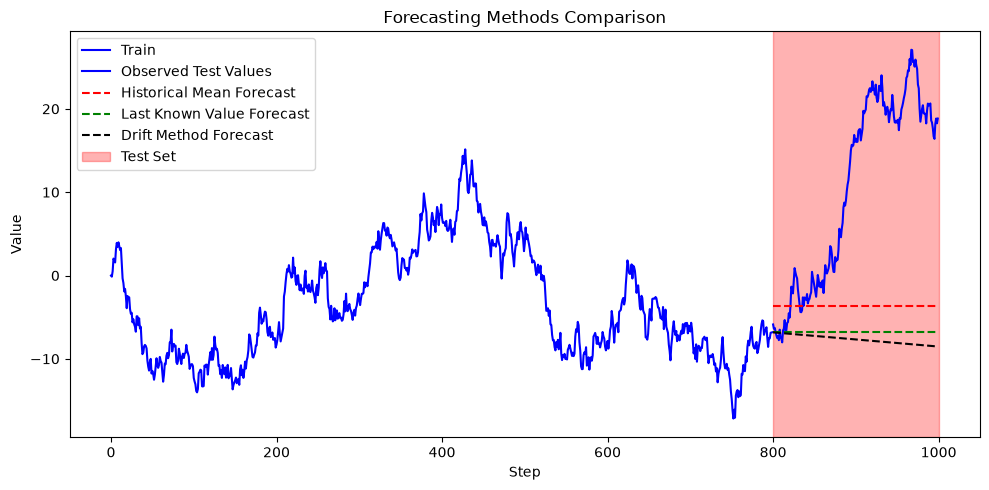

In [34]:
# Visualise all of these forecasts from the three methods (historical mean, last known value, and drift method) along with the actual test values.
fig, ax = plt.subplots(figsize=(10, 5))

# Plot values in the train set
ax.plot(train['value'], 'b-', label='Train')

# Plot observed test values
ax.plot(test['value'], 'b-', label='Observed Test Values')

# Plot the forecast: historical mean (red), last known value (green), drift method (black)
ax.plot(test['pred_mean'], 'r--', label='Historical Mean Forecast')
ax.plot(test['pred_last'], 'g--', label='Last Known Value Forecast')
ax.plot(test['pred_drift'], 'k--', label='Drift Method Forecast')

ax.axvspan(800, 1000, color='red', alpha=0.3, label='Test Set')
ax.legend(loc=2)

ax.set_xlabel("Step")
ax.set_ylabel("Value")

plt.title("Forecasting Methods Comparison")
plt.tight_layout()
plt.show()

Calculate the error using the mean squared error (MSE) of our forecasts. MAPE cannot be used because random walk allows a value of zero and it is possible to have division of 0 when using MAPE.

In [37]:
# Calculate the Mean Squared Error (MSE) for each forecasting method to evaluate their performance.
mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

# Print the MSE results for each forecasting method
print(f"Mean Squared Error (Historical Mean): {mse_mean:.4f}")
print(f"Mean Squared Error (Last Observation): {mse_last:.4f}")
print(f"Mean Squared Error (Drift Method): {mse_drift:.4f}")

Mean Squared Error (Historical Mean): 326.5028
Mean Squared Error (Last Observation): 425.1726
Mean Squared Error (Drift Method): 465.9076


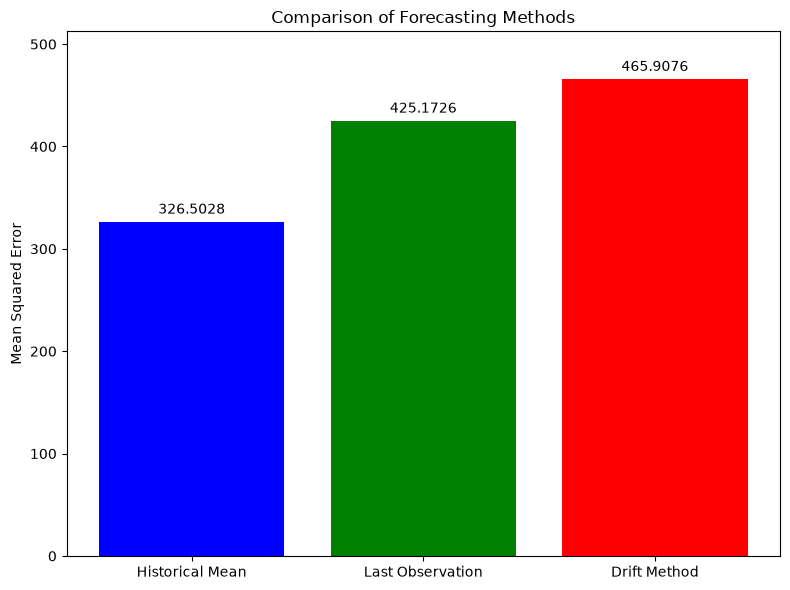

In [40]:
# Plot the MSE results for visual comparison
methods = ['Historical Mean', 'Last Observation', 'Drift Method']
mses = [mse_mean, mse_last, mse_drift]

plt.figure(figsize=(8, 6))
plt.bar(methods, mses, color=['blue', 'green', 'red'])
plt.ylabel('Mean Squared Error')
plt.title('Comparison of Forecasting Methods')
plt.ylim([0, max(mses) * 1.1])  # Set y-axis limit for better visualization

for i, v in enumerate(mses):
    plt.text(i, v + 0.01 * max(mses), f"{v:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Naive forecast of the next timestep**

Short-term forecasting is typically more reliable because the recent history of a time series is often informative for its immediate future. However, this assumption does **not** hold well for **random walks**.

A random walk moves unpredictably, with each step being a random shock added to the previous value. Because of this, even **short-term forecasts** are highly uncertain. The best we can do is assume that the **next value will be the same as the last observed one** - this is known as the **naive forecast of the next timestep**.

We use `df.shift(periods=1)` to create a new version of the series that is lagged by one time step.

In [41]:
# Shift the time series by one period to simulate a one-step-ahead forecast.
df_shifted = df.shift(1)

# Preview the first few rows of the shifted DataFrame
df_shifted.head()

,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


Notice that at step 1, the value is 0, which corresponds to the observed value at step 0 in the simulated random walk. We are now using the observed value as a forecast for the next timestep.

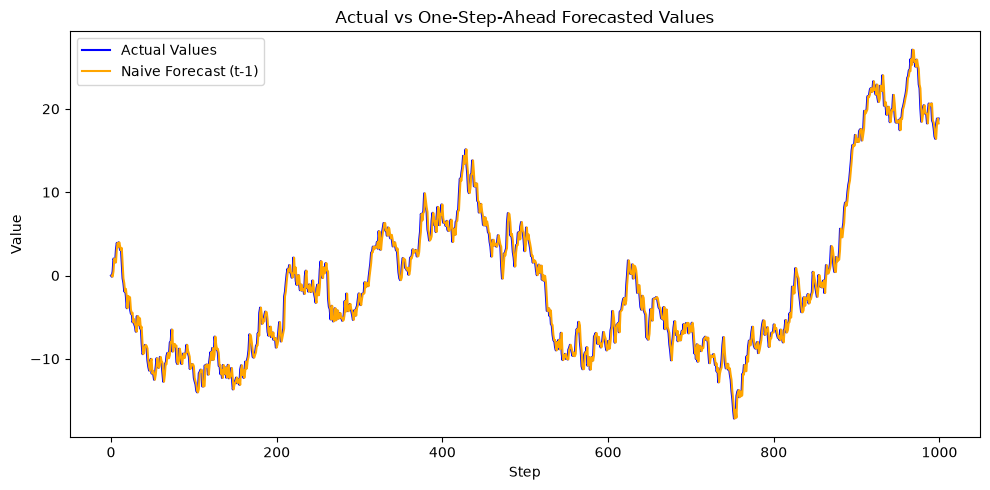

In [43]:
# Plot the actual vs one-step-ahead forecasted values to visualise the performance of the naive forecasting method.
fig, ax = plt.subplots(figsize=(10, 5))

# Blue = Actual values
ax.plot(df['value'], 'b-', label='Actual Values')

# Orange = One-step-ahead forecasted values (shifted)
ax.plot(df_shifted['value'], 'orange', label='Naive Forecast (t-1)')

ax.legend(loc=2)
ax.set_xlabel("Step")
ax.set_ylabel("Value")
ax.set_title("Actual vs One-Step-Ahead Forecasted Values")

plt.tight_layout()
plt.savefig('one_step_ahead_forecast.png', dpi=300)
plt.show()

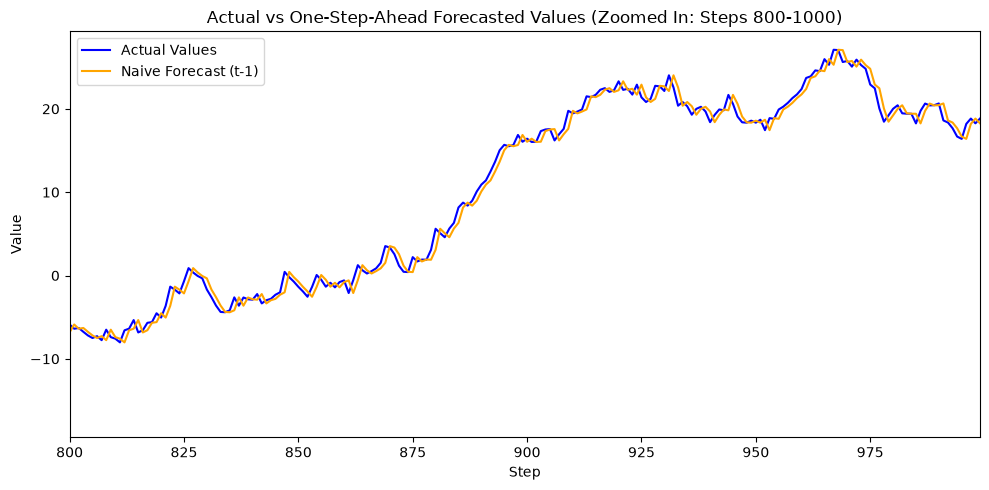

In [45]:
# Plot the actual vs predicted values for the one-step-ahead forecast using the shifted series (zoomed in)
fig, ax = plt.subplots(figsize=(10, 5))

# Blue = Actual values
ax.plot(df['value'], 'b-', label='Actual Values')
# Orange = One-step-ahead forecasted values (shifted)
ax.plot(df_shifted['value'], 'orange', label='Naive Forecast (t-1)')

# Zoom in on the last 200 steps of the series for better visualisation
ax.set_xlim(df.index[-200], df.index[-1])

ax.legend(loc=2)
ax.set_xlabel("Step")
ax.set_ylabel("Value")
ax.set_title("Actual vs One-Step-Ahead Forecasted Values (Zoomed In: Steps 800-1000)")
plt.tight_layout()
plt.show()

In [48]:
# The graph shows as a good model, but let's look at the MSE
mse_one_step = mean_squared_error(test['value'], df_shifted['value'][800:])  # Exclude the first NaN value
print(f"Mean Squared Error (Naive Forecast): {mse_one_step:.4f}")

Mean Squared Error (Naive Forecast): 0.9257


We have a good mean square error which is closer to 0 but we know that we are only forecasting the value observed at the previous timestep.

We know that random walk is not good in forecasting long horizon. However, we can say that is a random walk process must be forecast, it is better to make many short-term forecasts.

#### **Part 4: Analysing Real Data (Google Stock Prices)**

Next, we will load the dataset that contains Alphabet's (Google's) historical stock prices. Make sure the CSV file is in your working directory or provide the correct path.

We will use `pandas` to read the CSV file into a DataFrame.

In [51]:
# Read the CSV file containing the Google stock data into a DataFrame
df_google = pd.read_csv('./data/GOOGL.csv', parse_dates=['Date'], index_col='Date')

In [52]:
df_google.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


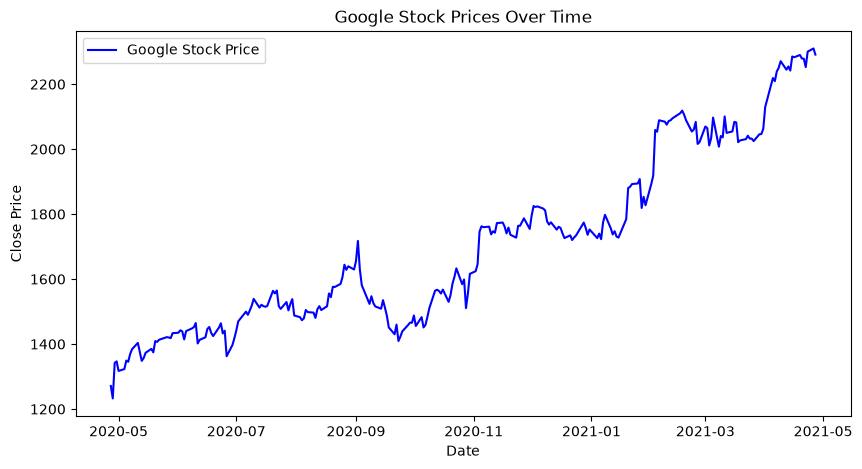

In [53]:
# Plot the data to visualise the Google stock prices over time.
plt.figure(figsize=(10, 5))
plt.plot(df_google['Close'], label='Google Stock Price', color='blue')
plt.title('Google Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

**Is GOOGL a random walk?**

Looking at the closing price in the previous Figure, we can observe an upward trend over time. This visual cue suggests the series is **non-stationary** - its mean changes over time.

To confirm this, we apply the **Augmented Dickey-Fuller (ADF) test** to the original `Close` price series:

In [54]:
# ADF test on the Google stock prices to check for stationarity
run_adf_test(df_google['Close'], "Google Stock Prices")

Augmented Dickey-Fuller Test: Google Stock Prices
ADF Test Statistic               0.160250
p-value                          0.969942
#Lags Used                       8.000000
Number of Observations Used    244.000000
Critical Value (1%)             -3.457438
Critical Value (5%)             -2.873459
Critical Value (10%)            -2.573122
Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.


In our case:

- ADF statistic $\approx$ 0.16
- p-value > 0.05

This confirms the series is **non-stationary**, consistent with the upward trend observed.

**First order differencing**

To remove the trend and attempt to stabilise the mean, we apply first-order differencing:

In [55]:
diff_close = df_google['Close'].diff().dropna()
run_adf_test(diff_close, "Google Stock Prices (Differenced)")

Augmented Dickey-Fuller Test: Google Stock Prices (Differenced)
ADF Test Statistic              -5.303440
p-value                          0.000005
#Lags Used                       7.000000
Number of Observations Used    244.000000
Critical Value (1%)             -3.457438
Critical Value (5%)             -2.873459
Critical Value (10%)            -2.573122
Strong evidence against the null hypothesis (reject H0), the series is stationary.


In this case:

- ADF statistic $\approx$ -5.30
- p-value < 0.05

This result indicates the differenced series is **stationary**.

**4.1.2 Autocorrelation Function**

To further understand the structure of the differenced closing prices, we plot the **autocorrelation function (ACF)** using 20 lags:

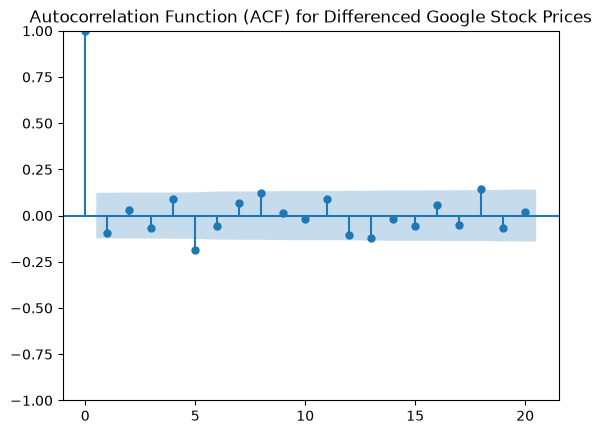

In [56]:
plot_acf(diff_close, lags=20, title='Autocorrelation Function (ACF) for Differenced Google Stock Prices')
plt.show()

The plot shows no clear pattern of autocorrelation. Except for minor spikes at lags 5 and 18, most autocorrelations fall within the confidence bounds.

In practice, this pattern suggests that these **isolated spikes are likely due to random chance**, especially since:

- There are no consecutive significant lags
- There is no consistent structure or decay in autocorrelation

Therefore, we can interpret this result as **evidence of no meaningful autocorrelation**.

**4.2 Conclusion**

Based on:

- The **non-stationarity** of the original `Close` series
- The **stationarity** of the first-differenced series
- The **lack of autocorrelation** in the differenced values

We can reasonably conclude that **GOOGL's closing price follows a random walk process**.

The first differences behave like **white noise**, meaning that future price changes are essentially **random and unpredictable** - a characteristic often observed in financial time series.

**4.3 Next Steps**

Since GOOGL's closing price behaves like a **random walk**, this limits what we can reasonably expect from forecasting:

- We can use **naive forecasting methods** such as the **last observed value** or **drift**, which are appropriate for random walk processes.
- However, we should not expect highly accurate forecasts, especially over a **long horizon**, as future movements are essentially random.
- Forecast accuracy will typically **decrease the further we predict into the future**, because random walks accumulate uncertainty over time.

In short, when modelling financial time series like stock prices, it is often better to focus on **short-term forecasting** and to evaluate models relative to simple baselines like the **naive forecast**.

---

**Key Takeaways**

- A **random walk** is a non-stationary time series whose **first difference is stationary and uncorrelated**.

- We verified that GOOGL's closing price is a random walk using:
    - The **ADF test** (non-stationary in level, stationary in first difference)
    - The **ACF plot** (no significant autocorrelation after differencing)

- This implies that:
    - This series is **unpredictable** in the long run
    - **Naive methods** are reasonable for forecasting
    - **Advanced models** may not outperform simple baselines for such data